<a href="https://colab.research.google.com/github/driano1221/amazon-vgames-dadosfera/blob/main/INF610_Exploracao_Dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# INF 610 — Exploração Inicial dos Dados
## Redes Bayesianas: Asia e Alarm

**Aluno:** Adriano Pires Cunha | **Matrícula:** 127545 | **UFV 2026/1**

Este notebook realiza a exploração estatística completa dos dois datasets:
- **Asia** (8 variáveis binárias) — usado na comparação direta dos 3 algoritmos
- **Alarm** (37 variáveis discretas) — usado no teste de escalabilidade

---

In [18]:
# Instalação dos pacotes (execute apenas uma vez)
pkgs <- c(
  "bnlearn",     # algoritmos de structure learning
  "ggplot2",     # visualizações
  "dplyr",       # manipulação de dados
  "tidyr",       # pivot_longer
  "reshape2",    # melt (heatmaps)
  "igraph",      # visualização de DAGs (plot estatico)
  "visNetwork",  # DAGs interativos (benchmark)
  "scales"       # formatação de eixos
)

novos <- pkgs[!pkgs %in% installed.packages()[, "Package"]]
if (length(novos) > 0) {
  cat("Instalando:", paste(novos, collapse = ", "), "\n")
  install.packages(novos, repos = "https://cran.r-project.org", quiet = TRUE)
}


In [19]:
library(bnlearn)
library(ggplot2)
library(dplyr)
library(tidyr)
library(reshape2)
library(visNetwork)
library(scales)

set.seed(42)  # reprodutibilidade


---
## 1. Dataset Asia

Rede Bayesiana sintética proposta por **Lauritzen & Spiegelhalter (1988)**.
- 8 variáveis binárias (yes/no) | 5.000 observações
- Estrutura verdadeira (ground truth) completamente documentada
- Disponível diretamente via `data(asia)` no bnlearn

In [20]:
data(asia)

cat("=== VISÃO GERAL DO DATASET ASIA ===\n")
cat("Dimensões:", nrow(asia), "observações x", ncol(asia), "variáveis\n")
cat("Valores ausentes:", sum(is.na(asia)), "\n\n")

desc <- data.frame(
  Nó        = c("A", "S", "T", "L", "B", "E", "X", "D"),
  Nome      = c("Asia", "Smoking", "Tuberculosis", "LungCancer",
                "Bronchitis", "Either", "XRay", "Dyspnea"),
  Descrição = c("Visitou Ásia?", "Fumante?", "Tuberculose?",
                "Câncer de pulmão?", "Bronquite?",
                "Tuberculose OU câncer? (T v L)",
                "Raio-X positivo?", "Dispneia?"),
  Pais      = c("∅", "∅", "A", "S", "S", "T, L", "E", "B, E"),
  check.names = FALSE
)
print(desc, row.names = FALSE)

=== VISÃO GERAL DO DATASET ASIA ===
Dimensões: 5000 observações x 8 variáveis
Valores ausentes: 0 

 Nó         Nome                      Descrição Pais
  A         Asia                  Visitou Ásia?    ∅
  S      Smoking                       Fumante?    ∅
  T Tuberculosis                   Tuberculose?    A
  L   LungCancer              Câncer de pulmão?    S
  B   Bronchitis                     Bronquite?    S
  E       Either Tuberculose OU câncer? (T v L) T, L
  X         XRay               Raio-X positivo?    E
  D      Dyspnea                      Dispneia? B, E


In [21]:
# P(X = 'yes') para cada variável
p_yes <- sapply(asia, function(x) mean(x == "yes"))

marg_df <- data.frame(
  Var    = names(p_yes),
  P_yes  = round(p_yes, 4),
  N_yes  = as.integer(colSums(asia == "yes")),
  N_no   = as.integer(colSums(asia == "no")),
  Classe = ifelse(p_yes < 0.05, "Raro (P < 5%)", "Comum (P >= 5%)")
)

cat("Frequências marginais:\n")
print(marg_df, row.names = FALSE)
cat("\nVariáveis com classe rara:",
    paste(marg_df$Var[marg_df$P_yes < 0.05], collapse = ", "), "\n")
cat("  -> Baixa frequência dificulta testes de independência (menor poder)\n")

Frequências marginais:
 Var  P_yes N_yes N_no          Classe
   A 0.0084    42 4958   Raro (P < 5%)
   S 0.5030  2515 2485 Comum (P >= 5%)
   T 0.0088    44 4956   Raro (P < 5%)
   L 0.0660   330 4670 Comum (P >= 5%)
   B 0.5098  2549 2451 Comum (P >= 5%)
   E 0.0740   370 4630 Comum (P >= 5%)
   X 0.1138   569 4431 Comum (P >= 5%)
   D 0.4700  2350 2650 Comum (P >= 5%)

Variáveis com classe rara: A, T 
  -> Baixa frequência dificulta testes de independência (menor poder)


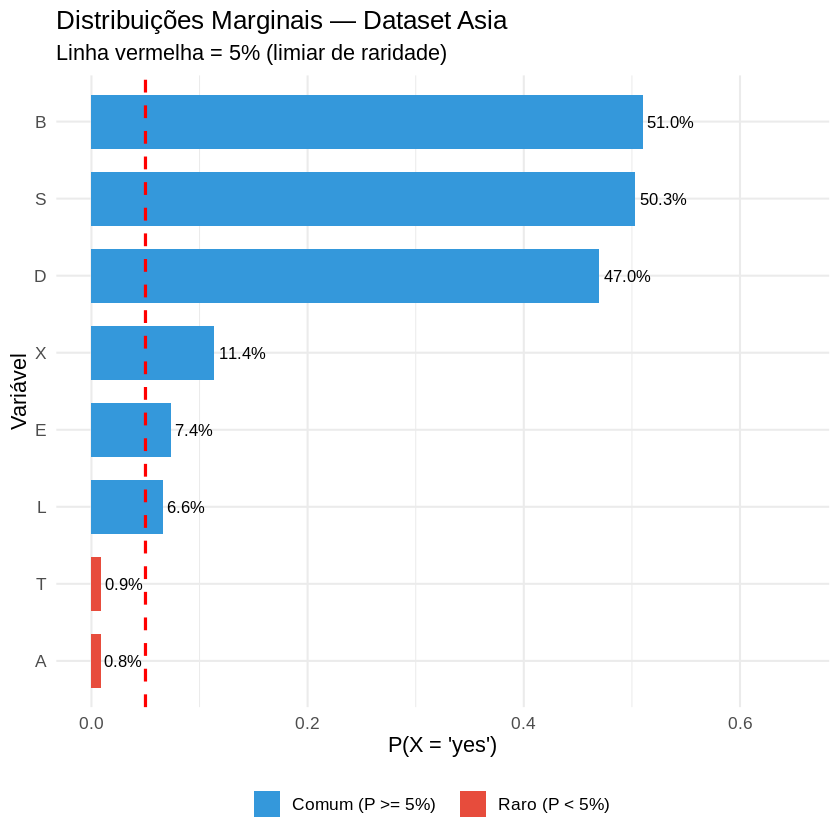

In [22]:
ggplot(marg_df, aes(x = reorder(Var, P_yes), y = P_yes, fill = Classe)) +
  geom_col(width = 0.7) +
  geom_hline(yintercept = 0.05, linetype = "dashed",
             color = "red", linewidth = 0.9) +
  geom_text(aes(label = percent(P_yes, accuracy = 0.1)),
            hjust = -0.1, size = 3.5) +
  coord_flip(ylim = c(0, 0.65)) +
  scale_fill_manual(
    values = c("Raro (P < 5%)" = "#E74C3C",
               "Comum (P >= 5%)" = "#3498DB"),
    name = NULL
  ) +
  labs(
    title    = "Distribuições Marginais — Dataset Asia",
    subtitle = "Linha vermelha = 5% (limiar de raridade)",
    x = "Variável", y = "P(X = 'yes')"
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

In [6]:
# Cramér's V — medida de associação para variáveis categóricas [0, 1]
# V = 0: independentes | V = 1: associação perfeita
cramer_v <- function(x, y) {
  tab  <- table(x, y)
  n    <- sum(tab)
  chi2 <- suppressWarnings(chisq.test(tab, correct = FALSE)$statistic)
  k    <- min(nrow(tab), ncol(tab))
  as.numeric(sqrt(chi2 / (n * (k - 1))))
}

vars  <- names(asia)
nv    <- length(vars)
V_mat <- matrix(NA_real_, nv, nv, dimnames = list(vars, vars))

for (i in seq_len(nv))
  for (j in seq_len(nv))
    V_mat[i, j] <- if (i == j) 1 else cramer_v(asia[[vars[i]]], asia[[vars[j]]])

cat("Matriz de Cramér's V:\n")
print(round(V_mat, 3))

cat("\nPares com associação forte (V > 0.3):\n")
for (i in seq_len(nv - 1)) {
  for (j in (i+1):nv) {
    if (V_mat[i,j] > 0.3)
      cat(sprintf("  %s <-> %s: V = %.3f\n", vars[i], vars[j], V_mat[i,j]))
  }
}

Matriz de Cramér's V:
      A     S     T     L     B     E     X     D
A 1.000 0.021 0.038 0.011 0.024 0.024 0.022 0.023
S 0.021 1.000 0.001 0.209 0.418 0.197 0.160 0.311
T 0.038 0.001 1.000 0.009 0.024 0.333 0.263 0.061
L 0.011 0.209 0.009 1.000 0.066 0.940 0.737 0.181
B 0.024 0.418 0.024 0.066 1.000 0.068 0.055 0.659
E 0.024 0.197 0.333 0.940 0.068 1.000 0.784 0.190
X 0.022 0.160 0.263 0.737 0.055 0.784 1.000 0.156
D 0.023 0.311 0.061 0.181 0.659 0.190 0.156 1.000

Pares com associação forte (V > 0.3):
  S <-> B: V = 0.418
  S <-> D: V = 0.311
  T <-> E: V = 0.333
  L <-> E: V = 0.940
  L <-> X: V = 0.737
  B <-> D: V = 0.659
  E <-> X: V = 0.784


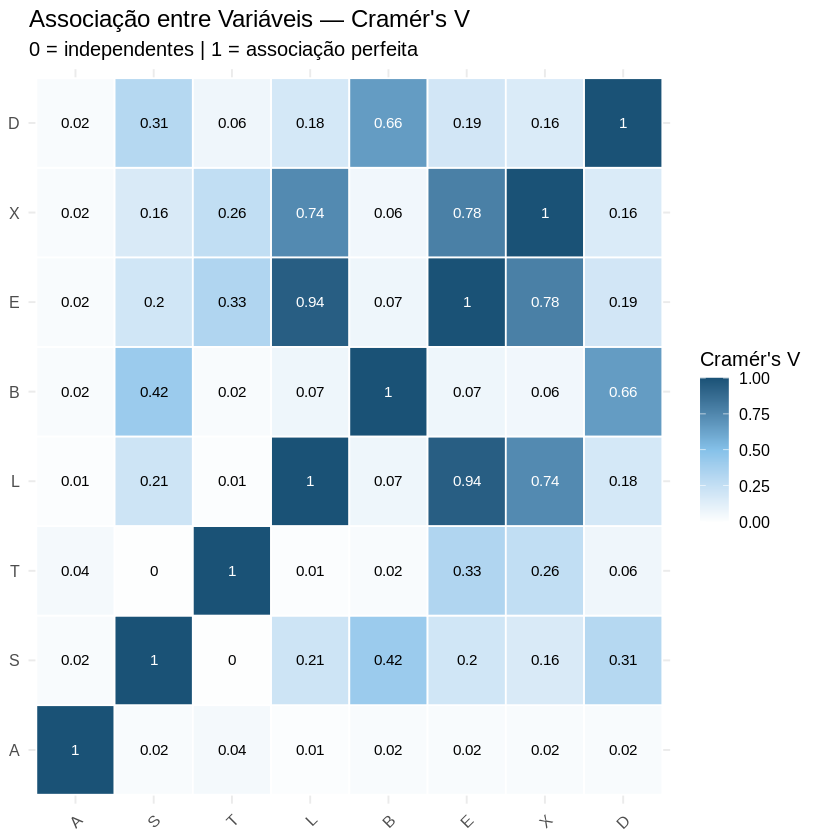

In [7]:
V_df <- melt(V_mat, varnames = c("Var1", "Var2"), value.name = "V")

ggplot(V_df, aes(x = Var1, y = Var2, fill = V)) +
  geom_tile(color = "white", linewidth = 0.5) +
  geom_text(aes(label = round(V, 2)), size = 3.2,
            color = ifelse(V_df$V > 0.5, "white", "black")) +
  scale_fill_gradientn(
    colours = c("#FDFEFE", "#85C1E9", "#1A5276"),
    limits  = c(0, 1),
    name    = "Cramér's V"
  ) +
  labs(
    title    = "Associação entre Variáveis — Cramér's V",
    subtitle = "0 = independentes | 1 = associação perfeita",
    x = NULL, y = NULL
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [8]:
cat("=== DISTRIBUIÇÕES CONDICIONAIS CHAVE ===\n\n")

# P(L | S): Câncer de pulmão dado tabagismo
cat("P(LungCancer | Smoking):")
print(round(prop.table(table(L = asia$L, S = asia$S), margin = 2), 3))
cat("  -> Fumantes têm ~10x mais risco de câncer\n\n")

# P(T | A): Tuberculose dado visita à Ásia
cat("P(Tuberculosis | Asia):")
print(round(prop.table(table(T = asia$T, A = asia$A), margin = 2), 3))
cat("  -> Visita à Ásia eleva o risco de tuberculose\n\n")

# P(D | E, B): Dispneia dado Either e Bronquite
cat("P(Dyspnea | Either, Bronchitis):")
print(round(prop.table(table(D = asia$D, E = asia$E, B = asia$B), margin = 2:3), 3))

# Verificar a porta OR determinística: E = T v L
cat("\nVerificação da porta OR — E = T v L:\n")
tbl <- table(E = asia$E, T = asia$T, L = asia$L)
cat("  P(E=yes | T=no, L=no) =",
    round(tbl['yes','no','no'] / sum(tbl[,'no','no']), 4),
    "(deve ser ~0)\n")
cat("  P(E=yes | T=yes, L=no) =",
    round(tbl['yes','yes','no'] / sum(tbl[,'yes','no']), 4),
    "(deve ser ~1)\n")

=== DISTRIBUIÇÕES CONDICIONAIS CHAVE ===

P(LungCancer | Smoking):     S
L        no   yes
  no  0.986 0.882
  yes 0.014 0.118
  -> Fumantes têm ~10x mais risco de câncer

P(Tuberculosis | Asia):     A
T        no   yes
  no  0.992 0.952
  yes 0.008 0.048
  -> Visita à Ásia eleva o risco de tuberculose

P(Dyspnea | Either, Bronchitis):, , B = no

     E
D        no   yes
  no  0.900 0.277
  yes 0.100 0.723

, , B = yes

     E
D        no   yes
  no  0.214 0.146
  yes 0.786 0.854


Verificação da porta OR — E = T v L:
  P(E=yes | T=no, L=no) = 0 (deve ser ~0)
  P(E=yes | T=yes, L=no) = 1 (deve ser ~1)


In [9]:
# Estrutura verdadeira do Asia DAG
asia_dag <- model2network("[A][S][T|A][L|S][B|S][E|T:L][X|E][D|B:E]")

cat("=== ESTRUTURA VERDADEIRA — ASIA DAG ===\n")
cat("Nós:", paste(nodes(asia_dag), collapse = ", "), "\n")
cat("Arestas:\n")
print(arcs(asia_dag))
cat("\nTotal de arestas:", nrow(arcs(asia_dag)), "\n")

cat("\nPais de cada nó:\n")
for (n in nodes(asia_dag)) {
  pa <- parents(asia_dag, n)
  cat(sprintf("  Pa(%-14s) = {%s}\n", n,
              if (length(pa) == 0) '∅' else paste(pa, collapse = ', ')))
}

# Análise do grafo
deg_in  <- sapply(nodes(asia_dag), function(n) length(parents(asia_dag, n)))
deg_out <- sapply(nodes(asia_dag), function(n) length(children(asia_dag, n)))
cat("\nNó com mais pais:",
    names(which.max(deg_in)), "(", max(deg_in), "pais — E = T v L)\n")
cat("Nó com mais filhos:",
    names(which.max(deg_out)), "(", max(deg_out), "filhos)\n")

=== ESTRUTURA VERDADEIRA — ASIA DAG ===
Nós: A, B, D, E, L, S, T, X 
Arestas:
     from to 
[1,] "A"  "T"
[2,] "S"  "L"
[3,] "S"  "B"
[4,] "T"  "E"
[5,] "L"  "E"
[6,] "E"  "X"
[7,] "B"  "D"
[8,] "E"  "D"

Total de arestas: 8 

Pais de cada nó:
  Pa(A             ) = {∅}
  Pa(B             ) = {S}
  Pa(D             ) = {B, E}
  Pa(E             ) = {L, T}
  Pa(L             ) = {S}
  Pa(S             ) = {∅}
  Pa(T             ) = {A}
  Pa(X             ) = {E}

Nó com mais pais: D ( 2 pais — E = T v L)
Nó com mais filhos: E ( 2 filhos)



Attaching package: ‘igraph’


The following object is masked from ‘package:tidyr’:

    crossing


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:bnlearn’:

    as.igraph, compare, degree, subgraph


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union




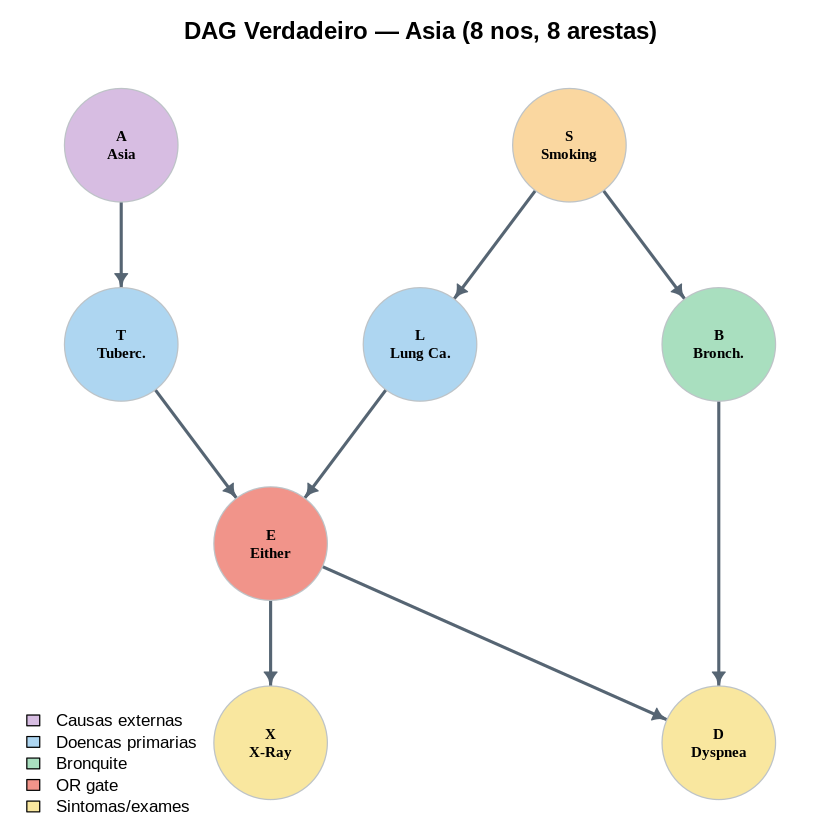

In [10]:
# visNetwork nao renderiza automaticamente no Colab R
# Solucao: usar igraph + plot() — sempre funciona
library(igraph)

asia_g <- graph_from_data_frame(
  d        = as.data.frame(arcs(asia_dag)),
  directed = TRUE,
  vertices = data.frame(name = nodes(asia_dag))
)

# Cores por grupo semantico
cores_asia <- c(
  A = "#D7BDE2", S = "#FAD7A0",   # causas externas
  T = "#AED6F1", L = "#AED6F1",   # doencas primarias
  B = "#A9DFBF",                   # bronquite
  E = "#F1948A",                   # either (OR gate)
  X = "#F9E79F", D = "#F9E79F"    # sintomas/exames
)

rotulos_asia <- c(
  A="A\nAsia", S="S\nSmoking", T="T\nTuberc.",
  L="L\nLung Ca.", B="B\nBronch.",
  E="E\nEither",  X="X\nX-Ray",  D="D\nDyspnea"
)

lay <- layout_with_sugiyama(asia_g)$layout

par(mar = c(0.5, 0.5, 2.5, 0.5), bg = "white")
plot(asia_g,
  layout             = lay,
  vertex.color       = cores_asia[V(asia_g)$name],
  vertex.size        = 38,
  vertex.label       = rotulos_asia[V(asia_g)$name],
  vertex.label.color = "black",
  vertex.label.cex   = 0.75,
  vertex.label.font  = 2,
  vertex.frame.color = "#BDC3C7",
  edge.arrow.size    = 0.55,
  edge.arrow.width   = 1.5,
  edge.color         = "#566573",
  edge.width         = 2.5,
  main               = "DAG Verdadeiro — Asia (8 nos, 8 arestas)"
)

legend("bottomleft", bty = "n", cex = 0.85,
  legend = c("Causas externas", "Doencas primarias",
             "Bronquite", "OR gate", "Sintomas/exames"),
  fill   = c("#D7BDE2", "#AED6F1", "#A9DFBF", "#F1948A", "#F9E79F")
)

### 1.1 Subgrafo de 5 nós — Busca Exaustiva

| | Asia-5 | Asia-8 | Alarm-37 |
|---|---|---|---|
| Nós | 5 | 8 | 37 |
| DAGs possíveis | 29.281 | ~784 bilhões | > 10⁵⁰ |
| Busca Exaustiva | ✅ ~30ms | ❌ dias | ❌ impossível |

Subconjunto escolhido: `{A, T, E, X, D}` — cadeia causal completa da tuberculose.

Subgrafo Asia-5: {A, T, E, X, D}
Arestas: 4 
DAGs possiveis (n=5, OEIS A003024): 29.281



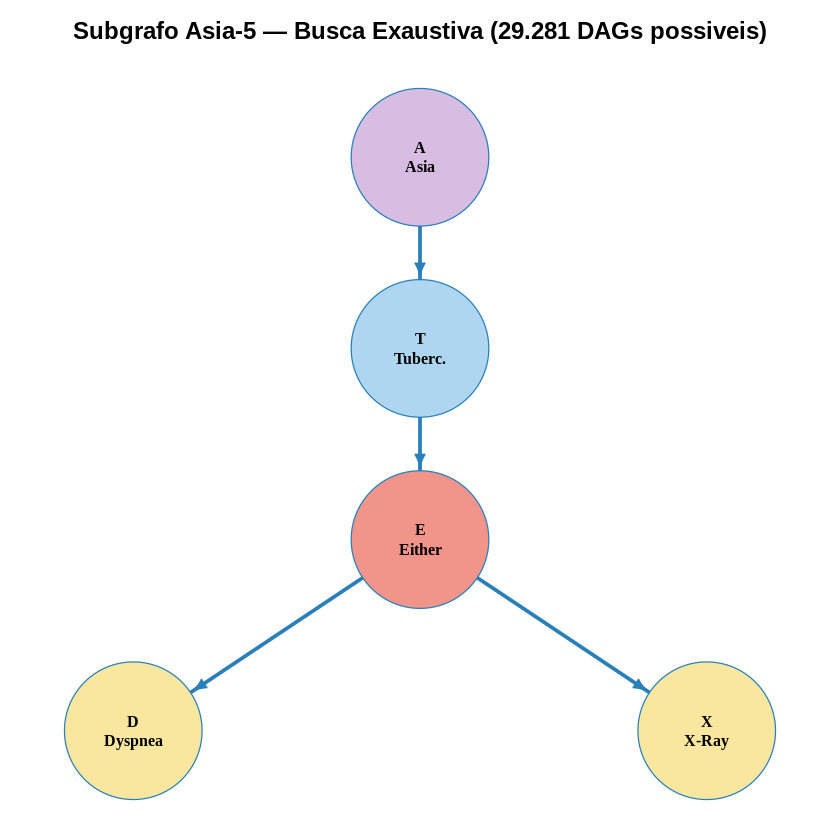

In [11]:
asia5_dag <- model2network("[A][T|A][E|T][X|E][D|E]")

cat("Subgrafo Asia-5: {A, T, E, X, D}\n")
cat("Arestas:", nrow(arcs(asia5_dag)), "\n")
cat("DAGs possiveis (n=5, OEIS A003024): 29.281\n\n")

asia5_g <- graph_from_data_frame(
  d        = as.data.frame(arcs(asia5_dag)),
  directed = TRUE,
  vertices = data.frame(name = nodes(asia5_dag))
)

cores5    <- c(A="#D7BDE2", T="#AED6F1", E="#F1948A",
               X="#F9E79F", D="#F9E79F")
rotulos5  <- c(A="A\nAsia", T="T\nTuberc.", E="E\nEither",
               X="X\nX-Ray", D="D\nDyspnea")

# Layout hierarquico: cadeia causal da esquerda para a direita
lay5 <- layout_with_sugiyama(asia5_g)$layout

par(mar = c(0.5, 0.5, 2.5, 0.5), bg = "white")
plot(asia5_g,
  layout             = lay5,
  vertex.color       = cores5[V(asia5_g)$name],
  vertex.size        = 48,
  vertex.label       = rotulos5[V(asia5_g)$name],
  vertex.label.color = "black",
  vertex.label.cex   = 0.80,
  vertex.label.font  = 2,
  vertex.frame.color = "#2980B9",
  edge.arrow.size    = 0.65,
  edge.color         = "#2980B9",
  edge.width         = 3,
  main               = "Subgrafo Asia-5 — Busca Exaustiva (29.281 DAGs possiveis)"
)

---
## 2. Dataset Alarm

Rede de monitoramento de alarmes em UTI — **Beinlich et al. (1989)**.
- 37 variáveis discretas (2–4 níveis) | até 20.000 observações
- 46 arestas — grafo esparso (~6,9% do máximo possível)
- Usado para demonstrar **escalabilidade** dos algoritmos aproximados

In [12]:
data(alarm)

if (!is.data.frame(alarm)) {
  cat("alarm é um objeto bn — simulando 10.000 observações...\n")
  alarm_data <- as.data.frame(rbn(alarm, n = 10000))
} else {
  alarm_data <- alarm
  cat("alarm é data.frame.\n")
}

cat("\n=== VISÃO GERAL DO DATASET ALARM ===\n")
cat("Dimensões:", nrow(alarm_data), "x", ncol(alarm_data), "\n")
cat("Valores ausentes:", sum(is.na(alarm_data)), "\n\n")
cat("Tipo de cada variável:\n")
cat("  Fatores:", sum(sapply(alarm_data, is.factor)), "\n")
cat("  Níveis únicos por variável (mín/máx):",
    min(sapply(alarm_data, function(x) length(unique(x)))), "/",
    max(sapply(alarm_data, function(x) length(unique(x)))), "\n")

alarm é data.frame.

=== VISÃO GERAL DO DATASET ALARM ===
Dimensões: 20000 x 37 
Valores ausentes: 0 

Tipo de cada variável:
  Fatores: 37 
  Níveis únicos por variável (mín/máx): 2 / 4 


Distribuição de níveis:
Niveis
 2  3  4 
13 17  7 


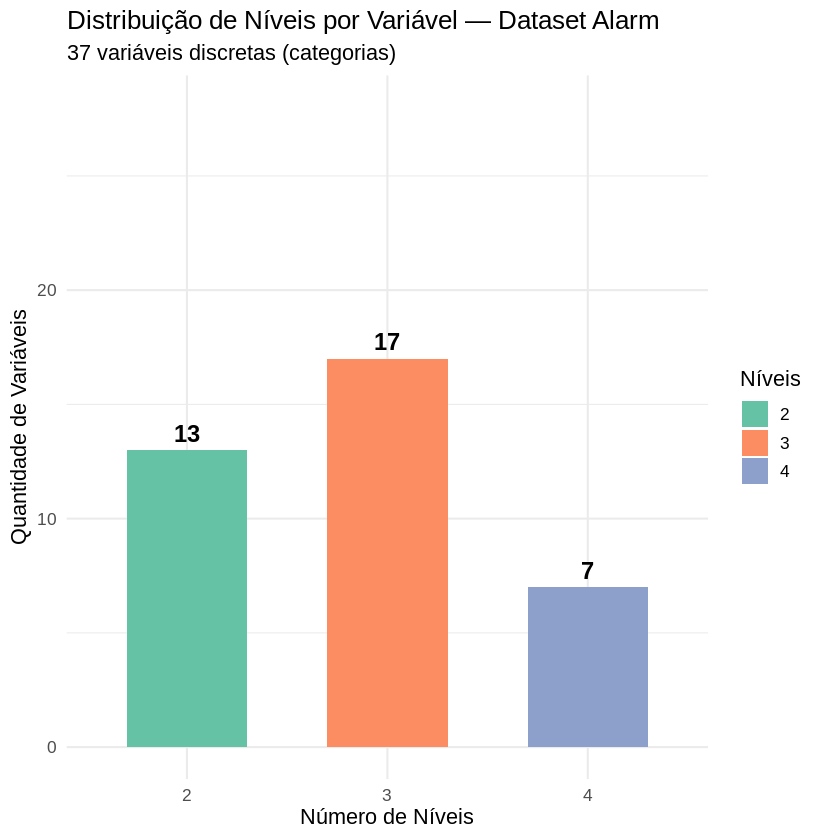

In [13]:
n_niveis <- sapply(alarm_data, function(x) length(unique(x)))

niveis_df <- data.frame(
  variavel = names(n_niveis),
  niveis   = n_niveis
) |> arrange(desc(niveis))

cat("Distribuição de níveis:\n")
print(table(Niveis = niveis_df$niveis))

ggplot(niveis_df, aes(x = factor(niveis), fill = factor(niveis))) +
  geom_bar(width = 0.6) +
  geom_text(stat = "count", aes(label = after_stat(count)),
            vjust = -0.5, size = 5, fontface = "bold") +
  scale_fill_brewer(palette = "Set2", name = "Níveis") +
  labs(
    title    = "Distribuição de Níveis por Variável — Dataset Alarm",
    subtitle = "37 variáveis discretas (categorias)",
    x = "Número de Níveis", y = "Quantidade de Variáveis"
  ) +
  theme_minimal(base_size = 13) +
  ylim(0, 28)

In [14]:
# Propriedades literais do Alarm (artigo original)
n_nos_alarm    <- 37
n_arestas_alarm <- 46
max_arestas    <- n_nos_alarm * (n_nos_alarm - 1) / 2
densidade      <- round(n_arestas_alarm / max_arestas * 100, 2)

cat("=== PROPRIEDADES DO GRAFO ALARM ===\n")
cat("Nós:                    ", n_nos_alarm,    "\n")
cat("Arestas (verdadeiro):   ", n_arestas_alarm, "\n")
cat("Arestas possíveis (max):", max_arestas,    "\n")
cat("Densidade:              ", densidade, "%\n")
cat("\nConsequência: grafo esparso favorece o algoritmo PC\n")
cat("  (PC é eficiente quando o grau máximo d é pequeno)\n\n")

# Estatísticas de prevalência por variável
cat("Distribuição dos níveis mais frequentes (top 5 variáveis):\n")
top5 <- head(niveis_df[order(niveis_df$niveis, decreasing = TRUE), ], 5)
for (v in top5$variavel) {
  cat(sprintf("  %-12s: %s\n", v,
              paste(names(table(alarm_data[[v]])), collapse=" | ")))
}

=== PROPRIEDADES DO GRAFO ALARM ===
Nós:                     37 
Arestas (verdadeiro):    46 
Arestas possíveis (max): 666 
Densidade:               6.91 %

Consequência: grafo esparso favorece o algoritmo PC
  (PC é eficiente quando o grau máximo d é pequeno)

Distribuição dos níveis mais frequentes (top 5 variáveis):
  PRSS        : HIGH | LOW | NORMAL | ZERO
  ECO2        : HIGH | LOW | NORMAL | ZERO
  MINV        : HIGH | LOW | NORMAL | ZERO
  VALV        : HIGH | LOW | NORMAL | ZERO
  VLNG        : HIGH | LOW | NORMAL | ZERO


Aprendendo estrutura aproximada (HC) para análise de graus...

Estatísticas de grau (estrutura HC aproximada):
  Grau de entrada — média: 1.43 | máx: 3 ( VLNG )
  Grau de saída   — média: 1.43 | máx: 5 ( VALV )
  Nós raiz (sem pais):  6 
  Folhas (sem filhos):  10 


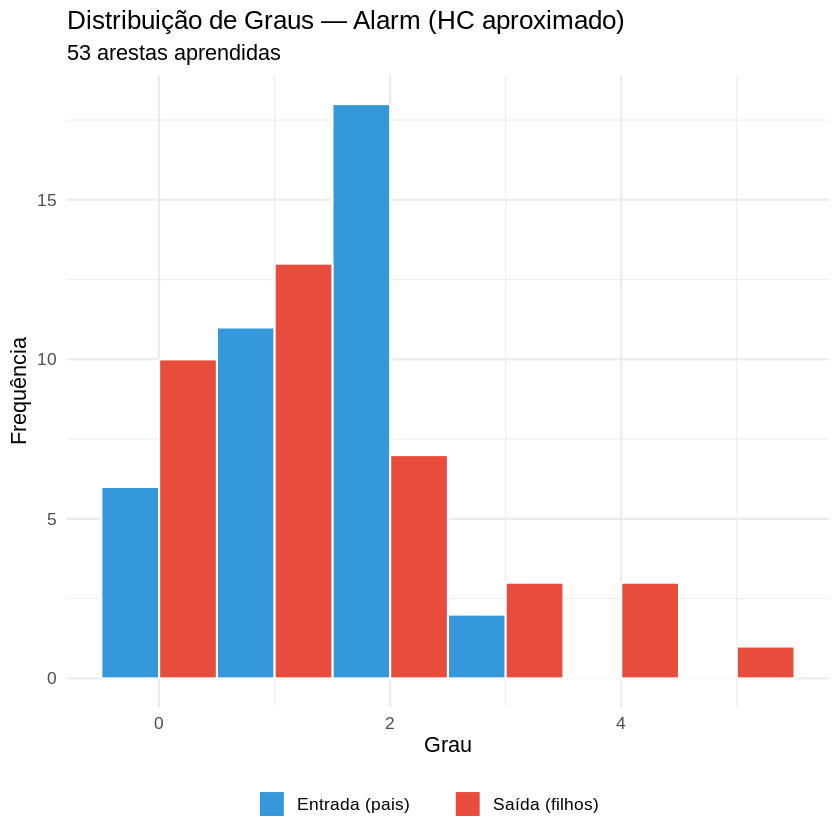

In [15]:
cat("Aprendendo estrutura aproximada (HC) para análise de graus...\n")
alarm_aprox <- hc(alarm_data, score = "bic")

grau_in  <- sapply(nodes(alarm_aprox), function(n) length(parents(alarm_aprox, n)))
grau_out <- sapply(nodes(alarm_aprox), function(n) length(children(alarm_aprox, n)))

cat("\nEstatísticas de grau (estrutura HC aproximada):\n")
cat("  Grau de entrada — média:", round(mean(grau_in), 2),
    "| máx:", max(grau_in),
    "(", names(which.max(grau_in)), ")\n")
cat("  Grau de saída   — média:", round(mean(grau_out), 2),
    "| máx:", max(grau_out),
    "(", names(which.max(grau_out)), ")\n")
cat("  Nós raiz (sem pais): ",  sum(grau_in  == 0), "\n")
cat("  Folhas (sem filhos): ",  sum(grau_out == 0), "\n")

# Gráfico de distribuição de graus
grau_df <- data.frame(
  no   = rep(names(grau_in), 2),
  tipo = rep(c("Entrada (pais)", "Saída (filhos)"), each = n_nos_alarm),
  grau = c(grau_in, grau_out)
)

ggplot(grau_df, aes(x = grau, fill = tipo)) +
  geom_histogram(binwidth = 1, position = "dodge", color = "white") +
  scale_fill_manual(
    values = c("Entrada (pais)" = "#3498DB", "Saída (filhos)" = "#E74C3C"),
    name = NULL
  ) +
  labs(
    title    = "Distribuição de Graus — Alarm (HC aproximado)",
    subtitle = paste0(nrow(arcs(alarm_aprox)), " arestas aprendidas"),
    x = "Grau", y = "Frequência"
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

Legenda:
 Vermelho = no raiz (sem pais)  | 6 nos
 Verde    = folha (sem filhos)  | 10 nos
 Azul     = intermediario       | 22 nos
 Tamanho proporcional ao numero de filhos



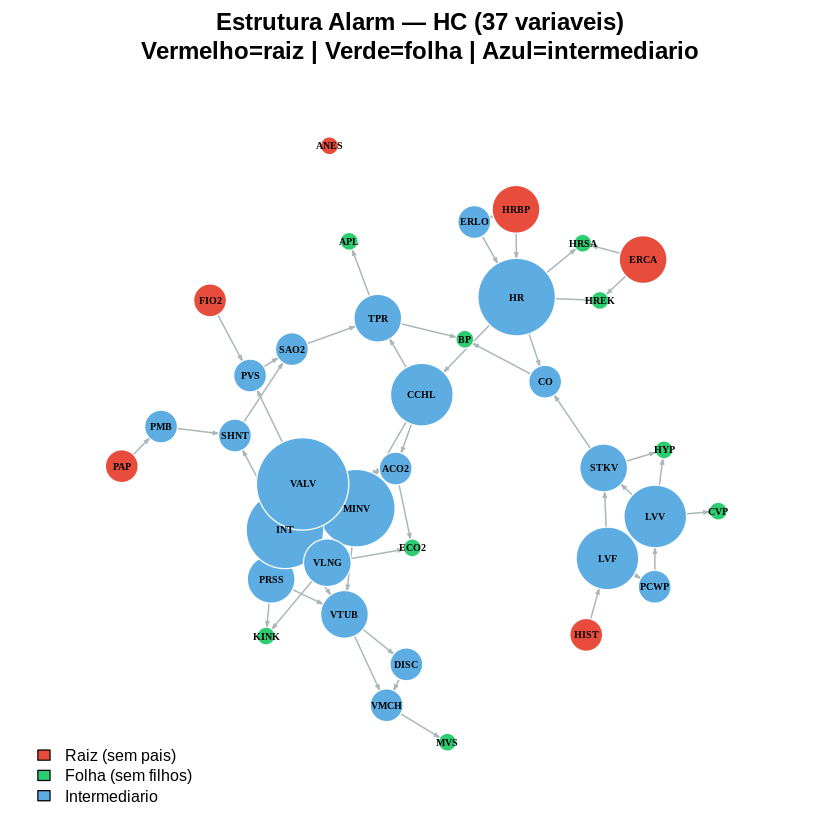

In [16]:
# Visualizacao do grafo Alarm com igraph
alarm_g <- graph_from_data_frame(
  d        = as.data.frame(arcs(alarm_aprox)),
  directed = TRUE,
  vertices = data.frame(name = nodes(alarm_aprox))
)

# Cor por papel no grafo
cor_no <- ifelse(grau_in  == 0, "#E74C3C",   # raiz: vermelho
         ifelse(grau_out == 0, "#2ECC71",   # folha: verde
                               "#5DADE2"))  # intermediario: azul
names(cor_no) <- names(grau_in)

# Tamanho proporcional ao numero de filhos
tam_no <- 6 + 5 * grau_out[V(alarm_g)$name]

cat("Legenda:\n")
cat(" Vermelho = no raiz (sem pais)  |", sum(grau_in  == 0), "nos\n")
cat(" Verde    = folha (sem filhos)  |", sum(grau_out == 0), "nos\n")
cat(" Azul     = intermediario       |", sum(grau_in > 0 & grau_out > 0), "nos\n")
cat(" Tamanho proporcional ao numero de filhos\n\n")

set.seed(42)
lay_alarm <- layout_with_fr(alarm_g)

par(mar = c(1, 1, 3, 1), bg = "white")
plot(alarm_g,
  layout             = lay_alarm,
  vertex.color       = cor_no[V(alarm_g)$name],
  vertex.size        = tam_no,
  vertex.label       = V(alarm_g)$name,
  vertex.label.cex   = 0.50,
  vertex.label.color = "black",
  vertex.label.font  = 2,
  vertex.frame.color = "white",
  edge.arrow.size    = 0.22,
  edge.color         = "#AAB7B8",
  edge.width         = 1.2,
  main               = "Estrutura Alarm — HC (37 variaveis)\nVermelho=raiz | Verde=folha | Azul=intermediario"
)

legend("bottomleft", bty = "n", cex = 0.80,
  legend = c("Raiz (sem pais)", "Folha (sem filhos)", "Intermediario"),
  fill   = c("#E74C3C", "#2ECC71", "#5DADE2")
)

---
## 3. Resumo Comparativo


In [17]:
resumo <- data.frame(
  Propriedade = c(
    "Nós", "Arestas (verdadeiro)", "Densidade",
    "Tipo de variáveis", "Níveis", "Observações",
    "Espaço de busca (DAGs)",
    "Busca Exaustiva", "Hill Climbing", "Algoritmo PC",
    "Papel no projeto"
  ),
  Asia_5nos = c(
    "5", "4", "40%", "Binárias", "2", "5.000",
    "29.281", "✅  ~30ms", "✅ Sim", "✅ Sim",
    "Comparação direta (3 algoritmos)"
  ),
  Asia_8nos = c(
    "8", "8", "28,6%", "Binárias", "2", "5.000",
    "~784 bilhões", "❌ dias", "✅ Sim", "✅ Sim",
    "HC vs PC (8 variáveis)"
  ),
  Alarm_37nos = c(
    "37", "46", "6,9%", "Discretas", "2 a 4", "10.000",
    "> 10^50", "❌ impossível", "✅ Sim", "✅ Sim",
    "Escalabilidade"
  ),
  check.names = FALSE
)

cat("=== RESUMO COMPARATIVO ===\n\n")
print(resumo, row.names = FALSE)

cat("\n=== PRÓXIMOS PASSOS ===\n")
cat("  1. Implementar busca_exaustiva() no Asia-5\n")
cat("  2. Wrappers de HC e PC com medição de tempo e métricas\n")
cat("  3. Benchmark completo (Experimentos 1-4)\n")
cat("  4. Diferenciais: Score Landscape, Edge-colored DAG, Learning Curve\n")

=== RESUMO COMPARATIVO ===

            Propriedade                        Asia_5nos              Asia_8nos
                    Nós                                5                      8
   Arestas (verdadeiro)                                4                      8
              Densidade                              40%                  28,6%
      Tipo de variáveis                         Binárias               Binárias
                 Níveis                                2                      2
            Observações                            5.000                  5.000
 Espaço de busca (DAGs)                           29.281           ~784 bilhões
        Busca Exaustiva                        ✅  ~30ms                ❌ dias
          Hill Climbing                           ✅ Sim                 ✅ Sim
           Algoritmo PC                           ✅ Sim                 ✅ Sim
       Papel no projeto Comparação direta (3 algoritmos) HC vs PC (8 variáveis)
    Alarm_37nos
  